Step 0: W=-1.0056, b=1.3123, loss=19.5207
Step 100: W=2.5459, b=1.9436, loss=1.3180
Step 200: W=2.9659, b=2.0110, loss=1.0649
Step 300: W=3.0156, b=2.0180, loss=1.0614
Step 400: W=3.0215, b=2.0187, loss=1.0613
Step 500: W=3.0222, b=2.0188, loss=1.0613
Step 600: W=3.0223, b=2.0188, loss=1.0613
Step 700: W=3.0223, b=2.0188, loss=1.0613
Step 800: W=3.0223, b=2.0188, loss=1.0613
Step 900: W=3.0223, b=2.0188, loss=1.0613


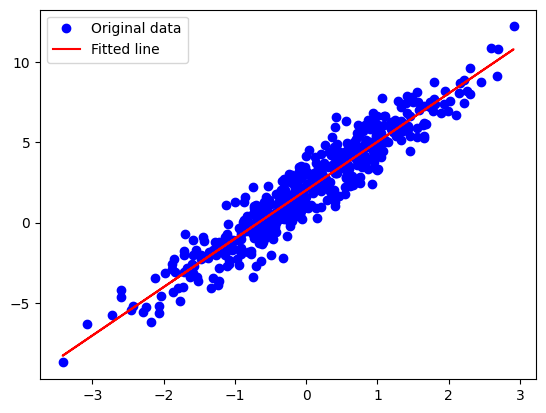

In [3]:
"""
author:-aam35
"""
import tensorflow as tf
import matplotlib.pyplot as plt

# Create data
NUM_EXAMPLES = 500

# define inputs and outputs with some noise
X = tf.random.normal([NUM_EXAMPLES])        # inputs
noise = tf.random.normal([NUM_EXAMPLES])    # noise
y = X * 3.0 + 2.0 + noise                   # true output

# Create trainable variables for W and b
W = tf.Variable(tf.random.normal([]))
b = tf.Variable(tf.random.normal([]))

train_steps = 1000
learning_rate = 0.01

# Define the linear predictor
def prediction(x):
    return W * x + b

# Define loss functions
def squared_loss(y, y_predicted):
    return tf.reduce_mean(tf.square(y - y_predicted))

def huber_loss(y, y_predicted, m=1.0):
    err = y - y_predicted
    abs_err = tf.abs(err)
    quadratic = tf.minimum(abs_err, m)
    linear = abs_err - quadratic
    return tf.reduce_mean(0.5 * tf.square(quadratic) + m * linear)

# Training loop
for i in range(train_steps):
    with tf.GradientTape() as tape:
        y_pred = prediction(X)
        loss = squared_loss(y, y_pred)   # 👈 switch to huber_loss(y, y_pred) if you want

    dW, db = tape.gradient(loss, [W, b])
    W.assign_sub(learning_rate * dW)
    b.assign_sub(learning_rate * db)

    if i % 100 == 0:
        print(f"Step {i}: W={W.numpy():.4f}, b={b.numpy():.4f}, loss={loss.numpy():.4f}")

# Plot results
plt.plot(X, y, 'bo', label='Original data')
plt.plot(X, prediction(X), 'r-', label='Fitted line')
plt.legend()
plt.show()
